In [11]:
import sys
sys.path.append(r"C:\Users\Rakesh\Documents\summer-project\src")

from two_level_mc import * # adjust if your notebook is nested differently
from functions_v2 import *

In [13]:
import numpy as np
import networkx as nx

In [15]:
# 1. Load
edges, n_vertices, edge_weights = load_graph(r"C:\Users\Rakesh\Documents\summer-project\data\raw\bio-CE-GN.edges")
edge_weights = None
print(f"Raw: n_vertices={n_vertices}, edges={len(edges)}")

# 2. Filter to largest connected component
G_nx = nx.Graph()
G_nx.add_edges_from(edges)
num_components = nx.number_connected_components(G_nx)
print(f"Components: {num_components}")

if num_components > 1:
    largest_cc = max(nx.connected_components(G_nx), key=len)
    G_sub = G_nx.subgraph(largest_cc).copy()
    all_nodes = sorted(largest_cc)
    node_map = {old: new for new, old in enumerate(all_nodes)}
    edges = [(node_map[i], node_map[j]) for i, j in G_sub.edges()]
    n_vertices = len(all_nodes)
    G_nx = nx.Graph()
    G_nx.add_edges_from(edges)

print(f"After cleanup: n_vertices={n_vertices}, edges={len(edges)}")

# 3. Phase 1
A, D, L = build_graph_matrices(edges, n_vertices)

# 4. Phase 2
lambda_min = compute_lambda_min(L, D)
L_sigma = build_shifted_laplacian(L, D, lambda_min)
print("L_sigma type:", type(L_sigma))

✓ Loaded: C:\Users\Rakesh\Documents\summer-project\data\raw\bio-CE-GN.edges
  Vertices : 2220
  Edges    : 53683
  Weighted : yes

Raw: n_vertices=2220, edges=53683
Components: 3
After cleanup: n_vertices=2215, edges=53680
✓ Phase 1 complete: A, D, L built as sparse matrices
  Matrix size : 2215 x 2215
  Degree range: [1, 242]
  Non-zeros in L: 109575

✓ lambda_min = 0.136723
  (eigenvalues found: [0.         0.13672322])
✓ Phase 2 complete: L_sigma built (sigma^2 = 0.25)
  L_sigma type: sparse

L_sigma type: <class 'scipy.sparse._csc.csc_matrix'>


In [13]:
from networkx.algorithms.community import greedy_modularity_communities, modularity

communities = list(greedy_modularity_communities(G_nx))
communities_sorted = sorted(communities, key=len, reverse=True)

print(f"Found {len(communities_sorted)} communities")
print(f"Sizes: {[len(c) for c in communities_sorted]}")

mod_score = modularity(G_nx, communities_sorted)
print(f"Modularity: {mod_score:.4f}")

gamma_in = list(communities_sorted[0])   # largest community
gamma_out = list(communities_sorted[1])  # second-largest community

print(f"\ngamma_in size: {len(gamma_in)}")
print(f"gamma_out size: {len(gamma_out)}")

overlap = set(gamma_in) & set(gamma_out)
print(f"Overlap (should be empty): {overlap}")

# the key check we now always do upfront - boundary fraction
boundary_fraction = (len(gamma_in) + len(gamma_out)) / n_vertices
print(f"Boundary fraction of total graph: {boundary_fraction:.4f}")

Found 16 communities
Sizes: [816, 736, 474, 56, 35, 29, 20, 15, 8, 7, 5, 4, 3, 3, 2, 2]
Modularity: 0.2638

gamma_in size: 816
gamma_out size: 736
Overlap (should be empty): set()
Boundary fraction of total graph: 0.7007


# Approach 2
- PROBLEM: Boundary fraction is way too large in this dataset because it predominatnly has 2 communities
- POSSIBLE SOLUTIONS :
      1. Pick 2 smallest communities instead - The problem with this is the 2 smallest communities can be noise. In this data, the 2 smallest communites have 2 nodes each. Using them as source and sink is not very meaningful since we cannot assume flow from 2 random communities.
      2. Pick a subset of nodes of the 2 dominant communities which have the highest degree nodes rather than using the entire communities as source and sink. This still preserves the dominance and connectivity of these communities to some extent.

In [16]:
import networkx as nx

G_nx = nx.Graph()
G_nx.add_edges_from(edges)

In [19]:
from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(G_nx))
communities_sorted = sorted(communities, key=len, reverse=True)

largest = communities_sorted[0]
second_largest = communities_sorted[1]

print(f"Largest community size: {len(largest)}")
print(f"Second largest community size: {len(second_largest)}")

Largest community size: 816
Second largest community size: 736


In [21]:
def top_degree_subset(community, G_nx, fraction=0.05):
    """
    Take the highest-degree vertices within a community, as a fraction
    of that community's size, to control boundary fraction while
    staying anchored to the graph's actual dominant structure.
    """
    community_list = list(community)
    degrees = [(v, G_nx.degree(v)) for v in community_list]
    degrees_sorted = sorted(degrees, key=lambda x: x[1], reverse=True)
    n_keep = max(1, int(len(community_list) * fraction))
    return [v for v, d in degrees_sorted[:n_keep]]

gamma_in = top_degree_subset(largest, G_nx, fraction=0.05)
gamma_out = top_degree_subset(second_largest, G_nx, fraction=0.05)

print(f"gamma_in: {len(gamma_in)} vertices (from community of {len(largest)})")
print(f"gamma_out: {len(gamma_out)} vertices (from community of {len(second_largest)})")

overlap = set(gamma_in) & set(gamma_out)
print(f"Overlap: {overlap}")

boundary_fraction = (len(gamma_in) + len(gamma_out)) / n_vertices
print(f"Boundary fraction: {boundary_fraction:.4f}")

gamma_in: 40 vertices (from community of 816)
gamma_out: 36 vertices (from community of 736)
Overlap: set()
Boundary fraction: 0.0343


In [23]:
aggregate_of, n_coarse = build_capped_aggregation(G_nx, gamma_in, gamma_out, max_size=10)
summary = summarize_aggregation(aggregate_of, n_coarse, gamma_in, gamma_out)

n_coarse: 1009 (1009 aggregates)
Size distribution -- min: 2, max: 10, mean: 2.20
Singletons: 0 (0.0%)
gamma_in_coarse: 40, gamma_out_coarse: 36
Overlap (must be empty): set()
Interior coarse vertices: 933 (92.5%)


gamma_in: 40, gamma_out: 36, n_vertices: 2215
Boundary fraction: 3.4312%
  -> Untested range -- proceed but verify interior_coarse is non-empty and substantial after aggregation.
n_coarse: 1009 (1009 aggregates)
Size distribution -- min: 2, max: 10, mean: 2.20
Singletons: 0 (0.0%)
gamma_in_coarse: 40, gamma_out_coarse: 36
Overlap (must be empty): set()
Interior coarse vertices: 933 (92.5%)
coarse edges: 46372 (from 53680 fine edges)


Paired samples: 100%|██████████| 100/100 [07:21<00:00,  4.42s/sample, Q_fine=2828.4475, Q_coarse=4522.6459]



N = 100 paired samples
Q_fine   : mean=2828.447456  var=15.776143
Q_coarse : mean=4522.645878  var=31.484819
Q_fine - Q_coarse : mean=-1694.198422  var=15.020314
Correlation(Q_fine, Q_coarse): 0.7233
Variance reduction: 1.05x


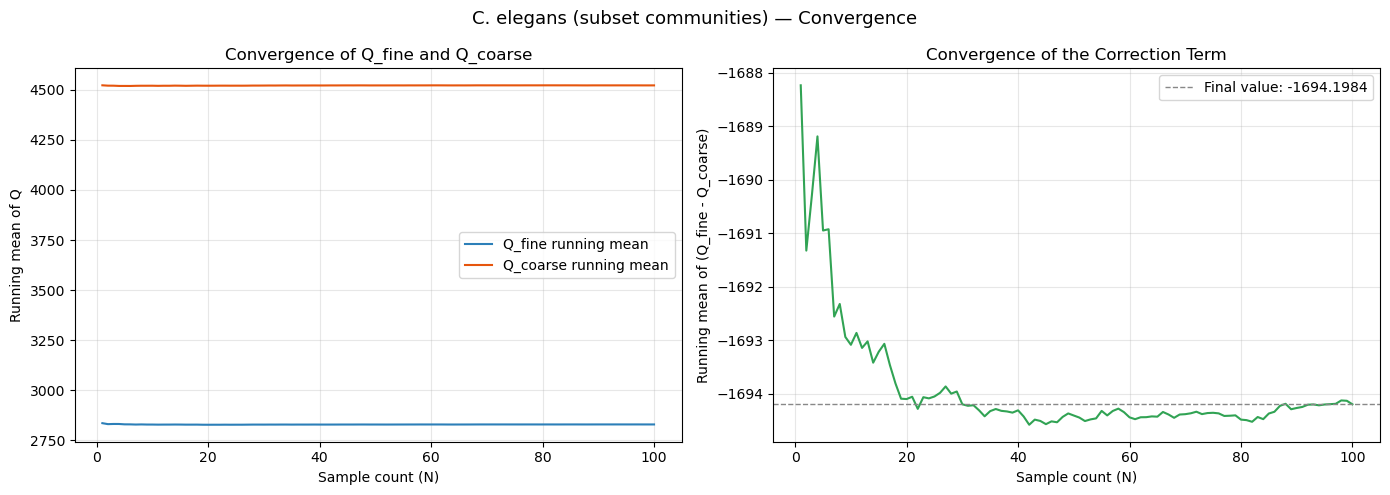

In [26]:
setup = TwoLevelSetup.build(
    edges, n_vertices, L_sigma, lambda_min,
    gamma_in, gamma_out,
    build_incidence_matrix, sparse_cholesky,
    max_size=10
)

result = run_paired_validation(setup, N=100)
plot_convergence(result, title="C. elegans (subset communities) — Convergence")